In [60]:
import numpy as np
from OptimalBattery.util import build_combinations
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import matplotlib.ticker as ticker


In [108]:
n_tasks = 29
n_parcel = 7

In [109]:
VL_rand = Vs = np.random.normal(0, 1, (n_tasks, n_parcel))
GL_rand = VL_rand @ VL_rand.T

In [110]:
offsets = np.logspace(-10, 10, num=1000)
D = build_combinations(G_lib=GL_rand,strategy='random',n_iter=100,offs = offsets, n_tasks=8,seed=1)

In [111]:
def plot_correlation(D,x='max_var',y='log_det'):
    corrs = []
    offsets = D['offset'].unique()
    for offset in offsets:
        data = D[D['offset']==offset]
        x_data = data[x]
        y_data = data[y]
        corr, _ = pearsonr(x_data, y_data)
        corrs.append(corr)
    plt.plot(offsets, corrs)
    plt.xscale('log')
    plt.xlabel('offset')
    plt.ylabel('correlation')
    plt.title(f'{x} vs {y}')
    plt.show()

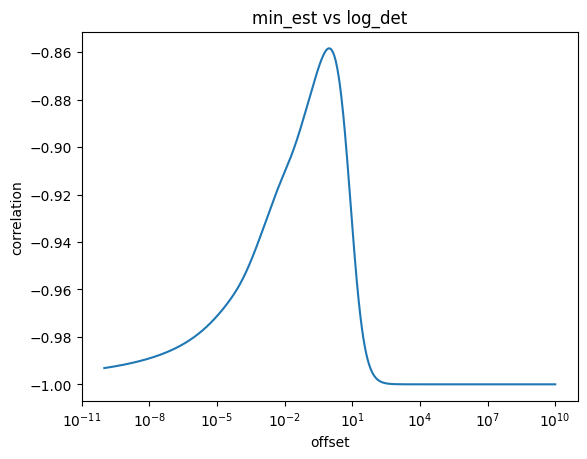

In [112]:
plot_correlation(D,x='min_est',y='log_det')



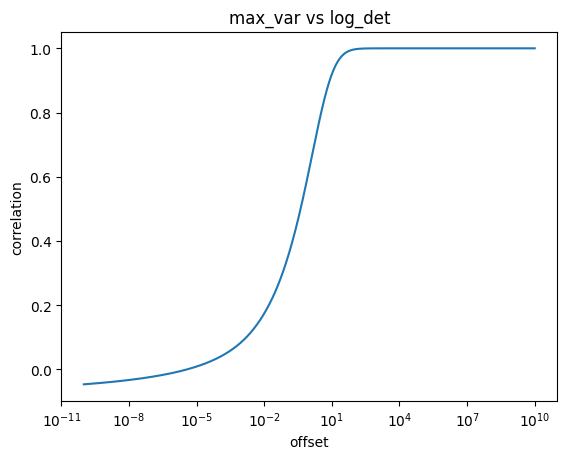

In [113]:
plot_correlation(D,x='max_var',y='log_det')

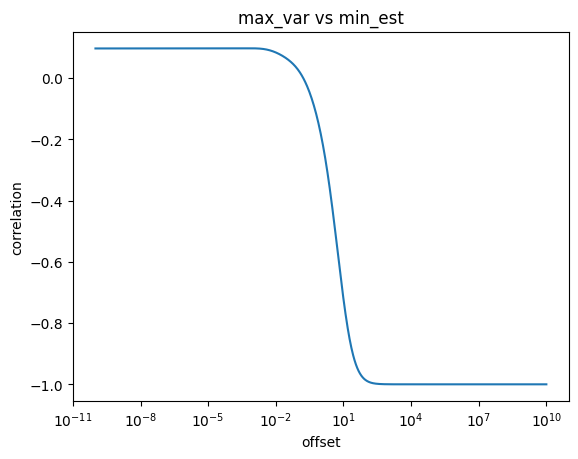

In [114]:
plot_correlation(D,x='max_var',y='min_est')

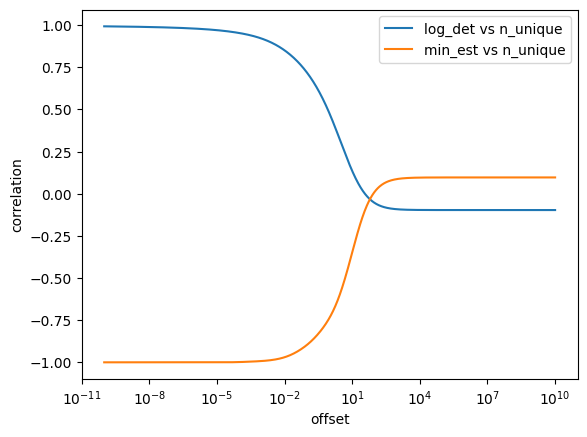

In [115]:
corrs = []
offsets = D['offset'].unique()
for offset in offsets:
    data = D[D['offset']==offset]
    x_data = data['n_unique']
    y_data = data['log_det']
    corr, _ = pearsonr(x_data, y_data)
    corrs.append(corr)
plt.plot(offsets, corrs, label='log_det vs n_unique')
corrs = []
for offset in offsets:
    data = D[D['offset']==offset]
    x_data = data['n_unique']
    y_data = data['min_est']
    corr, _ = pearsonr(x_data, y_data)
    corrs.append(corr)
plt.plot(offsets, corrs, label='min_est vs n_unique')
plt.xscale('log')
plt.xlabel('offset')
plt.ylabel('correlation')
plt.legend()
plt.show()



# mdtb covariance

<Axes: >

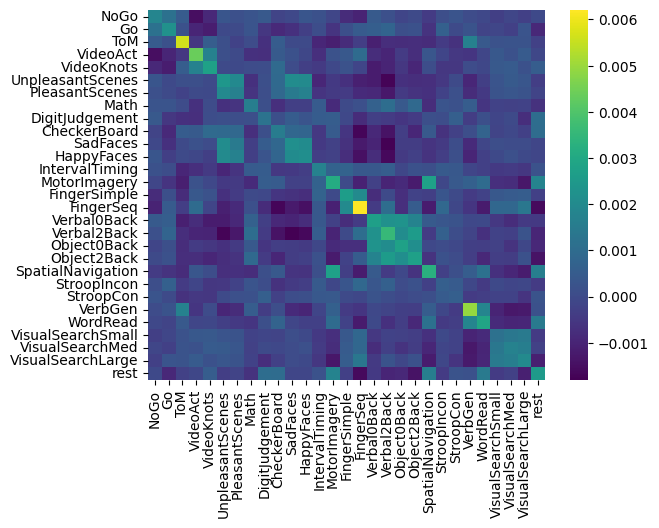

In [68]:
from IndividualParcellation.global_config import *
import numpy as np
import seaborn as sns
from Functional_Fusion.dataset import DataSetMDTB
import Functional_Fusion.atlas_map as am
import PcmPy as pcm
import os

base_dir = '/cifs/diedrichsen/data/FunctionalFusion'
if not os.path.exists(base_dir):
    base_dir = 'Y:/data/FunctionalFusion'
space = 'SUIT3'
atlas, _ = am.get_atlas(space)


MDTB_dataset = DataSetMDTB(f'{base_dir}/MDTB')
data_mdtb_s1,info_mdtb_1  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll')
task_names = info_mdtb_1.cond_name.values


MDTB_dataset = DataSetMDTB(f'{base_dir}/MDTB')
data_mdtb_s1,info_mdtb_1  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')

task_matrix = data_mdtb_s1 
task_matrix[np.isnan(task_matrix)] = 0

cond_vec = np.tile(np.arange(1, 29 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 29)

Gs_list = []
E_list = []
for i in range(task_matrix.shape[0]):
    Gs,E = pcm.util.est_G_crossval(task_matrix[i], cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_individuals_averaged = np.mean(Gs_list, axis=0)

sns.heatmap(G_individuals_averaged, cmap='viridis', xticklabels=task_names, yticklabels=task_names)

In [94]:
D_mdtv = build_combinations(G_lib=G_individuals_averaged,strategy='random',n_iter=100,offs = offsets, n_tasks=8,seed=1)

/home/ROBARTS/barafat/.local/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4461: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  warnings.warn(stats.NearConstantInputWarning(msg))


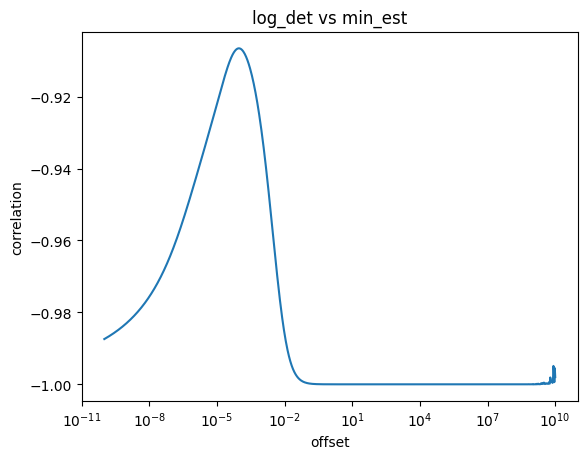

In [95]:
plot_correlation(D_mdtv,x='log_det',y='min_est')


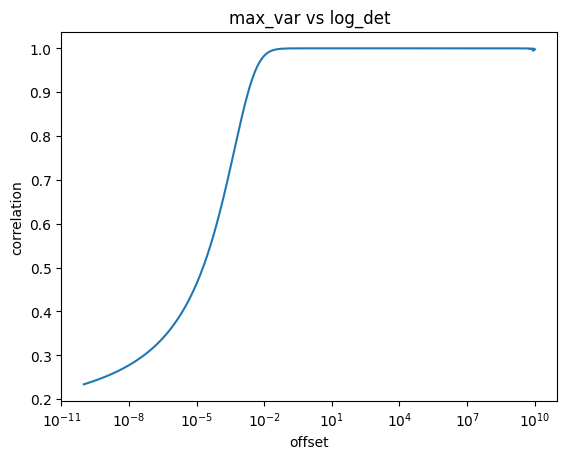

9.246257116405733e-05


In [96]:
plot_correlation(D_mdtv,x='max_var',y='log_det')

#find offset with highest correlation
corrs = []
offsets = D_mdtv['offset'].unique()
for offset in offsets:
    data = D_mdtv[D_mdtv['offset']==offset]
    x_data = data['min_est']
    y_data = data['log_det']
    corr, _ = pearsonr(x_data, y_data)
    corrs.append(corr)

best_offset = offsets[np.argmax(corrs)]
print(best_offset)


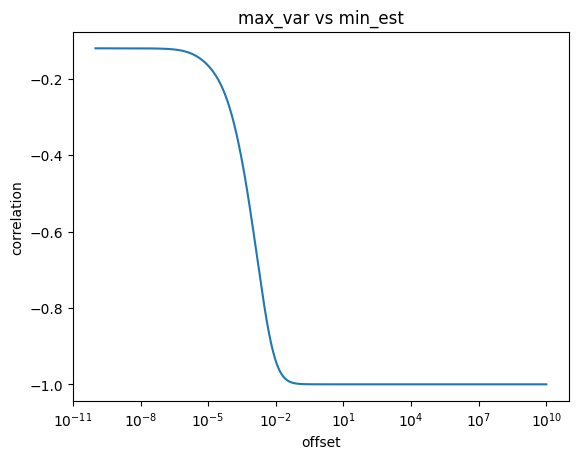

In [97]:
plot_correlation(D_mdtv,x='max_var',y='min_est')

/home/ROBARTS/barafat/.local/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4461: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  warnings.warn(stats.NearConstantInputWarning(msg))


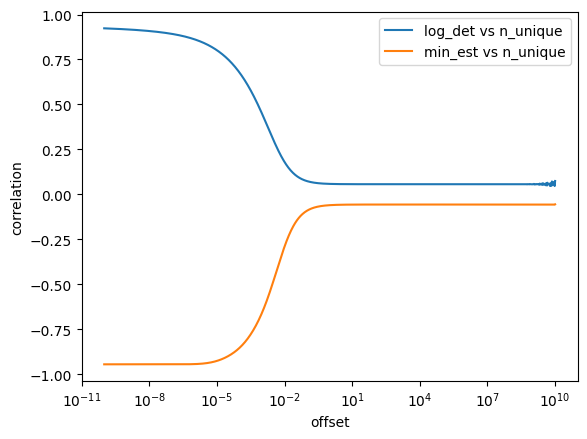

In [116]:
corrs = []
offsets = D_mdtv['offset'].unique()
for offset in offsets:
    data = D_mdtv[D_mdtv['offset']==offset]
    x_data = data['n_unique']
    y_data = data['log_det']
    corr, _ = pearsonr(x_data, y_data)
    corrs.append(corr)
plt.plot(offsets, corrs, label='log_det vs n_unique')
corrs = []
for offset in offsets:
    data = D_mdtv[D_mdtv['offset']==offset]
    x_data = data['n_unique']
    y_data = data['min_est']
    corr, _ = pearsonr(x_data, y_data)
    corrs.append(corr)
plt.plot(offsets, corrs, label='min_est vs n_unique')
plt.xscale('log')
plt.xlabel('offset')
plt.ylabel('correlation')
plt.legend()
plt.show()


In [98]:
# print correaltion between log_det and max_var at best_offset
data = D_mdtv[D_mdtv['offset']==best_offset]
x_data = data['max_var']
y_data = data['log_det']
corr, _ = pearsonr(x_data, y_data)
print(corr)

# print correaltion between max_var and min_est at best_offset
data = D_mdtv[D_mdtv['offset']==best_offset]
x_data = data['max_var']
y_data = data['min_est']
corr, _ = pearsonr(x_data, y_data)
print(corr)


0.6134091562670794
-0.2787234328046898


# looks like log_det cares about variance more than min_est, simulate scaneraio where they disagree

In [26]:

Matrix_A = np.array([
    [5.0, 4.5, 4.5],
    [4.5, 5.0, 4.5],
    [4.5, 4.5, 5.0]
])

Matrix_B = np.array([
    [1.0, 0.0, 0.0],
    [0.0, 1.5, 0.0],
    [0.0, 0.0, 2.0]
])


In [27]:
eigvals_A = np.linalg.eigvalsh(Matrix_A)
eigvals_B = np.linalg.eigvalsh(Matrix_B)

offset = 0.1
lex_A = eigvals_A + offset
lex_B = eigvals_B + offset

# Compute min_est (sum of inverses of eigenvalues)
min_est_A = np.sum(1 / lex_A)
min_est_B = np.sum(1 / lex_B)

# Compute log_det (sum of logs of eigenvalues)
log_det_A = np.sum(np.log(lex_A))
log_det_B = np.sum(np.log(lex_B))

print("\nMatrix A:")
print("eigvals:", eigvals_A)
print("  min_est:", min_est_A)
print("  log_det:", log_det_A)

print("\nMatrix B:")
print("eigvals:", eigvals_B)
print("  min_est:", min_est_B)
print("  log_det:", log_det_B)



Matrix A:
eigvals: [ 0.5  0.5 14. ]
  min_est: 3.404255319148935
  log_det: 1.6245235498521424

Matrix B:
eigvals: [1.  1.5 2. ]
  min_est: 2.0102813852813854
  log_det: 1.307251153779438


# quantify how much each metric cares about variance at different reguulariaxation factors

In [38]:
def compute_log_det(cov_matrix, offset):
    cov_matrix_reg = cov_matrix + np.eye(cov_matrix.shape[0]) * offset
    eigenvalues = np.linalg.eigvalsh(cov_matrix_reg)
    log_det = np.sum(np.log(eigenvalues))
    return log_det

def compute_min_est(cov_matrix, offset):
    cov_matrix_reg = cov_matrix + np.eye(cov_matrix.shape[0]) * offset
    eigenvalues = np.linalg.eigvalsh(cov_matrix_reg)
    min_est = np.sum(1 / eigenvalues)
    return min_est

In [39]:
# Define ranges for variance and correlation
variance_values = np.linspace(1, 10, 20)
correlation_values = np.linspace(0, 0.99, 20)

# Define different offsets to test
offset_values = [1e-8, 1e-6, 1e-4, 1e-2, 1, 1e2, 1e4, 1e6, 1e8]

In [45]:
from sklearn.linear_model import LinearRegression

offsets = []
perc_var_log_dets = []
perc_corr_log_dets = []
perc_var_min_ests = []
perc_corr_min_ests = []

for offset in offset_values:
    variance_list = []
    correlation_list = []
    log_det_values = []
    min_est_values = []

    for variance in variance_values:
        for correlation in correlation_values:
            covariance = correlation * variance

            # Create covariance matrix (3x3 for simplicity)
            cov_matrix = np.full((3, 3), covariance)
            np.fill_diagonal(cov_matrix, variance)

            # Compute metrics with the current offset
            log_det = compute_log_det(cov_matrix, offset)
            min_est = compute_min_est(cov_matrix, offset)

            # Append results to lists
            variance_list.append(variance)
            correlation_list.append(correlation)
            log_det_values.append(log_det)
            min_est_values.append(min_est)
    variance_array = np.array(variance_list)
    correlation_array = np.array(correlation_list)
    X = np.vstack((variance_array, correlation_array)).T
    y_log_det = np.array(log_det_values)
    y_min_est = np.array(min_est_values)

    # Perform linear regression for log_det
    model_log_det = LinearRegression()
    model_log_det.fit(X, y_log_det)
    coeff_log_det = model_log_det.coef_

    # Perform linear regression for min_est
    model_min_est = LinearRegression()
    model_min_est.fit(X, y_min_est)
    coeff_min_est = model_min_est.coef_

    # Calculate percentage contributions
    sum_coeff_log_det = np.sum(np.abs(coeff_log_det))
    sum_coeff_min_est = np.sum(np.abs(coeff_min_est))

    perc_var_log_det = (abs(coeff_log_det[0]) / sum_coeff_log_det) * 100
    perc_corr_log_det = (abs(coeff_log_det[1]) / sum_coeff_log_det) * 100

    perc_var_min_est = (abs(coeff_min_est[0]) / sum_coeff_min_est) * 100
    perc_corr_min_est = (abs(coeff_min_est[1]) / sum_coeff_min_est) * 100

    offsets.append(offset)
    perc_var_log_dets.append(perc_var_log_det)
    perc_corr_log_dets.append(perc_corr_log_det)
    perc_var_min_ests.append(perc_var_min_est)
    perc_corr_min_ests.append(perc_corr_min_est)


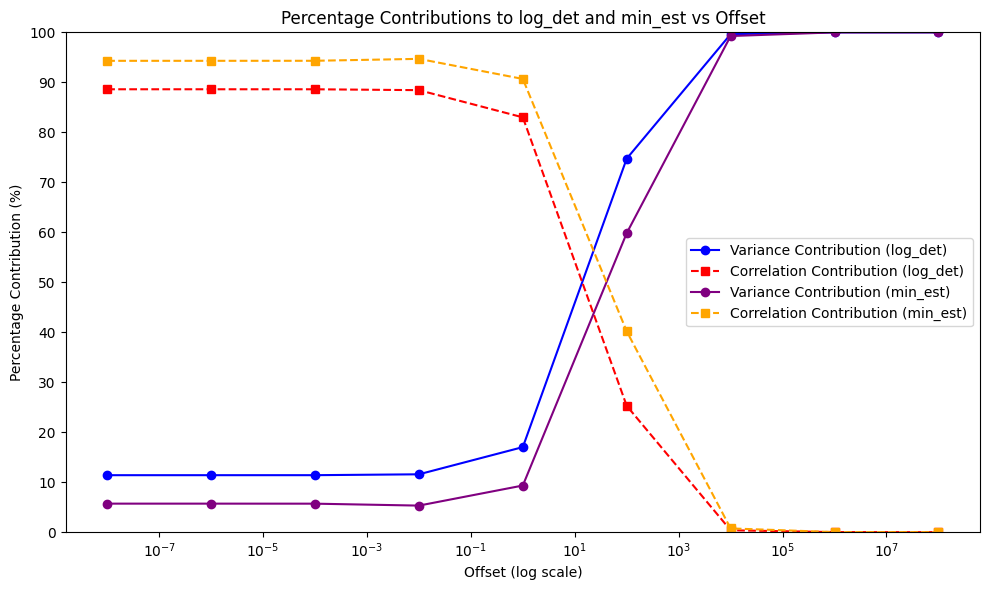

In [46]:
offsets_array = np.array(offsets)

plt.figure(figsize=(10, 6))

# Plot contributions for log_det
plt.plot(offsets_array, perc_var_log_dets, label='Variance Contribution (log_det)', marker='o', linestyle='-', color='blue')
plt.plot(offsets_array, perc_corr_log_dets, label='Correlation Contribution (log_det)', marker='s', linestyle='--', color='red')
plt.plot(offsets_array, perc_var_min_ests, label='Variance Contribution (min_est)', marker='o', linestyle='-', color='purple')
plt.plot(offsets_array, perc_corr_min_ests, label='Correlation Contribution (min_est)', marker='s', linestyle='--', color='orange')

plt.xscale('log')
plt.xlabel('Offset (log scale)')
plt.ylabel('Percentage Contribution (%)')
plt.title('Percentage Contributions to log_det and min_est vs Offset')

plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(nbins=10))
plt.ylim(0, 100)

plt.legend()
plt.tight_layout()
plt.show()
